# California Housing — ML Exercises 1, 2 & 3

| Exercise | Topic |
|---|---|
| **Exercise 1** | Baseline Regression + Error Analysis |
| **Exercise 2** | 'What-if' Sensitivity Analysis on a Single Feature |
| **Exercise 3** | Outlier Removal via Residuals (Robustness Check) |

**Dataset:** `sklearn.datasets.fetch_california_housing(as_frame=True)`  
**Model:** `Pipeline(StandardScaler(), LinearRegression())`


## Shared Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline


## Shared Data — Load & Split

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset shape : {df.shape}")
print(f"Features      : {list(X.columns)}")
print(f"Target range  : {y.min():.2f} – {y.max():.2f}  ($100k)")
print(f"Train / Test  : {len(X_train):,} / {len(X_test):,} samples")
df.head()


Dataset shape : (20640, 9)
Features      : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range  : 0.15 – 5.00  ($100k)
Train / Test  : 16,512 / 4,128 samples


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
---
# Exercise 1 — Baseline Regression + Error Analysis

**Goal:** Train a linear regression model to predict median house values and analyze where it fails.


## Task 3 — Train Baseline LinearRegression (no scaling)

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_baseline = lr.predict(X_test)

print("Baseline model trained.")
print("\nLearned coefficients:")
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_}).set_index("Feature")
print(coef_df.round(4).to_string())


Baseline model trained.

Learned coefficients:
            Coefficient
Feature                
MedInc           0.4487
HouseAge         0.0097
AveRooms        -0.1233
AveBedrms        0.7831
Population      -0.0000
AveOccup        -0.0035
Latitude        -0.4198
Longitude       -0.4337


## Task 4 — Evaluate: RMSE, MAE, R²

In [4]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae  = mean_absolute_error(y_test, y_pred_baseline)
r2   = r2_score(y_test, y_pred_baseline)

print("=" * 42)
print("  Baseline LinearRegression — Test Set")
print("=" * 42)
print(f"  RMSE : {rmse:.4f}  ($100k units)")
print(f"  MAE  : {mae:.4f}  ($100k units)")
print(f"  R²   : {r2:.4f}")
print("=" * 42)


  Baseline LinearRegression — Test Set
  RMSE : 0.7456  ($100k units)
  MAE  : 0.5332  ($100k units)
  R²   : 0.5758


## Task 5 — Results DataFrame

In [5]:
results = pd.DataFrame({
    "y_true":    y_test.values,
    "y_pred":    y_pred_baseline,
    "residual":  y_test.values - y_pred_baseline,
    "abs_error": np.abs(y_test.values - y_pred_baseline),
})

print(f"Results DataFrame shape: {results.shape}")
results.head(10).round(4)


Results DataFrame shape: (4128, 4)


,y_true,y_pred,residual,abs_error
0,0.477,0.7191,-0.2421,0.2421
1,0.458,1.7640,-1.3060,1.3060
2,5.000,2.7097,2.2904,2.2904
3,2.186,2.8389,-0.6529,0.6529
4,2.780,2.6047,0.1753,0.1753
5,1.587,2.0118,-0.4248,0.4248
6,1.982,2.6455,-0.6635,0.6635
7,1.575,2.1688,-0.5938,0.5938
8,3.400,2.7407,0.6593,0.6593
9,4.466,3.9156,0.5504,0.5504


## Task 6 — Worst 10 Predictions (largest absolute error)


In [6]:
worst10 = results.nlargest(10, "abs_error").reset_index(drop=True)
worst10.index += 1
worst10.round(4)


,y_true,y_pred,residual,abs_error
1,1.625,11.5003,-9.8753,9.8753
2,5.000,0.8516,4.1484,4.1484
3,5.000,1.1152,3.8848,3.8848
4,5.000,1.3200,3.6801,3.6801
5,4.500,0.8672,3.6328,3.6328
6,0.675,4.2362,-3.5612,3.5612
7,5.000,1.5475,3.4525,3.4525
8,5.000,1.6429,3.3571,3.3571
9,5.000,1.6680,3.3320,3.3320
10,5.000,1.7112,3.2889,3.2889


### 🔍 Error Analysis — What do the worst predictions have in common?

- **Negative residuals** → model over-predicts (predicted > actual)  
- **Positive residuals** → model under-predicts (predicted < actual)

The dataset **caps** `MedHouseVal` at **5.0** ($500k). High-income / well-located homes hit this ceiling,  
but the linear model extrapolates beyond it — causing the largest errors. This is a **label-censoring** artifact.


## Task 7 — Diagnostic Plots

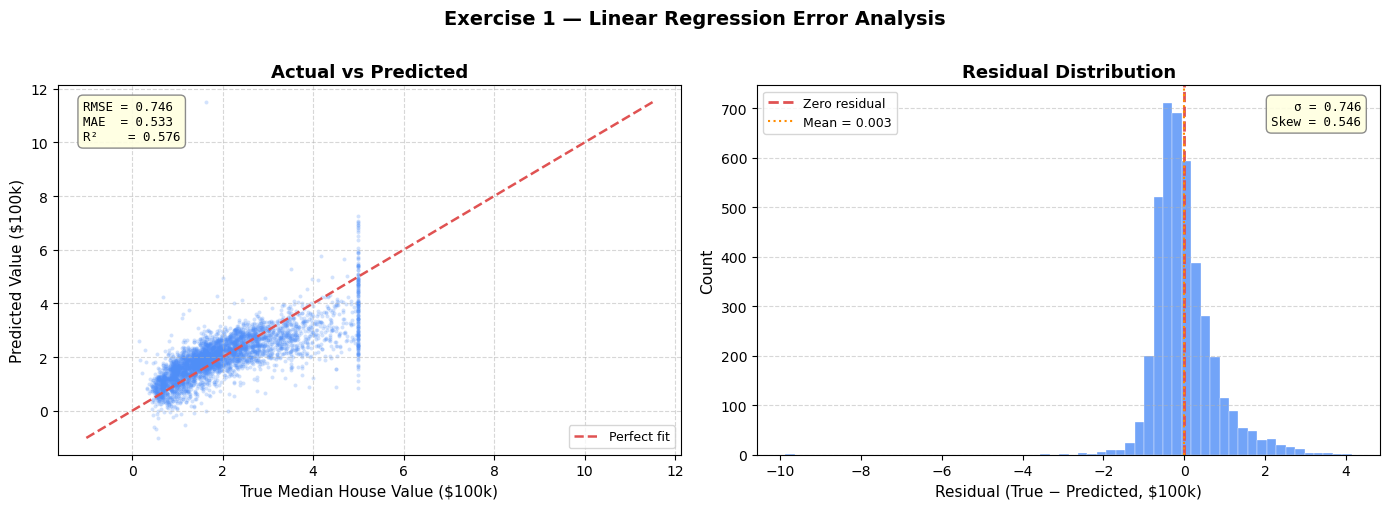

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: y_true vs y_pred ──────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_baseline, alpha=0.25, s=8, color="#4F8EF7", linewidths=0)

lo, hi = min(y_test.min(), y_pred_baseline.min()), max(y_test.max(), y_pred_baseline.max())
ax.plot([lo, hi], [lo, hi], color="#E05252", lw=1.8, ls="--", label="Perfect fit")

ax.set_xlabel("True Median House Value ($100k)", fontsize=11)
ax.set_ylabel("Predicted Value ($100k)", fontsize=11)
ax.set_title("Actual vs Predicted", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

metrics_txt = f"RMSE = {rmse:.3f}\nMAE  = {mae:.3f}\nR²    = {r2:.3f}"
ax.text(0.04, 0.96, metrics_txt, transform=ax.transAxes, fontsize=9,
        va="top", ha="left", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray", alpha=0.9))

# ── Plot 2: Residual histogram ─────────────────────────────────────────────────
ax = axes[1]
residuals = results["residual"].values

ax.hist(residuals, bins=60, color="#4F8EF7", alpha=0.80, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="#E05252", lw=2.0, ls="--", label="Zero residual")
ax.axvline(residuals.mean(), color="darkorange", lw=1.5, ls=":",
           label=f"Mean = {residuals.mean():.3f}")

ax.set_xlabel("Residual (True − Predicted, $100k)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Residual Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

stats_txt = f"σ = {residuals.std():.3f}\nSkew = {pd.Series(residuals).skew():.3f}"
ax.text(0.97, 0.96, stats_txt, transform=ax.transAxes, fontsize=9,
        va="top", ha="right", family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray", alpha=0.9))

fig.suptitle("Exercise 1 — Linear Regression Error Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## ⭐ Exercise 1 Bonus — Pipeline: StandardScaler + LinearRegression


In [8]:
pipe_ex1 = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression()),
])
pipe_ex1.fit(X_train, y_train)
y_pred_scaled = pipe_ex1.predict(X_test)

rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
mae_s  = mean_absolute_error(y_test, y_pred_scaled)
r2_s   = r2_score(y_test, y_pred_scaled)

comparison = pd.DataFrame({
    "Model":  ["Baseline (no scaling)", "Pipeline (StandardScaler)"],
    "RMSE":   [rmse,   rmse_s],
    "MAE":    [mae,    mae_s],
    "R²":     [r2,     r2_s],
})
print(comparison.round(6).to_string(index=False))
print(f"\nΔ RMSE : {rmse_s - rmse:+.8f}")
print(f"Δ MAE  : {mae_s  - mae:+.8f}")
print(f"Δ R²   : {r2_s   - r2:+.8f}")


                    Model     RMSE    MAE       R²
    Baseline (no scaling) 0.745581 0.5332 0.575788
Pipeline (StandardScaler) 0.745581 0.5332 0.575788

Δ RMSE : -0.00000000
Δ MAE  : +0.00000000
Δ R²   : +0.00000000


### 📝 Why doesn't scaling change the results?

**Short answer:** OLS linear regression is **scale-invariant**.

When you scale $X$ by a diagonal matrix $S$, the new coefficients become $\hat{\beta}' = S^{-1}\hat{\beta}$.  
The predictions $X\hat{\beta} = (XS)(S^{-1}\hat{\beta})$ are **identical**.

| Model | Scaling matters? | Why |
|---|---|---|
| LinearRegression (OLS) | ❌ No | Scale-invariant closed-form |
| Ridge / Lasso | ✅ Yes | L2/L1 penalty is scale-sensitive |
| SGD / Neural Networks | ✅ Yes | Gradient flow depends on scale |
| KNN / SVM | ✅ Yes | Distance metrics are scale-sensitive |

> **Takeaway:** Always scale anyway — it's required the moment you switch to a regularised or distance-based model.


---
---
# Exercise 2 — 'What-if' Sensitivity Analysis on a Single Feature

**Goal:** Quantify how changing one feature impacts predictions for a single sample.


## Task 1 — Train Pipeline(StandardScaler, LinearRegression)

In [9]:
# Reuse the same pipeline architecture (already trained above as pipe_ex1)
pipe = pipe_ex1   # Pipeline(StandardScaler → LinearRegression), fitted on X_train

print("Pipeline ready (trained in Exercise 1 Bonus).")


Pipeline ready (trained in Exercise 1 Bonus).


## Task 2 — Pick One Test Sample

In [10]:
sample_idx = 0
sample = X_test.iloc[[sample_idx]].copy()   # shape (1, 8)

base_pred = pipe.predict(sample)[0]

print("Reference sample (raw feature values):")
print(sample.T.rename(columns={sample.index[0]: "value"}).round(4).to_string())
print(f"\nBaseline prediction : {base_pred:.4f}  ($100k)")
print(f"True label          : {y_test.iloc[sample_idx]:.4f}  ($100k)")


Reference sample (raw feature values):
                value
MedInc         1.6812
HouseAge      25.0000
AveRooms       4.1922
AveBedrms      1.0223
Population  1392.0000
AveOccup       3.8774
Latitude      36.0600
Longitude   -119.0100

Baseline prediction : 0.7191  ($100k)
True label          : 0.4770  ($100k)


## Tasks 3 & 4 — Vary MedInc × 13 Multipliers, Predict Each

In [11]:
multipliers = np.linspace(0.7, 1.3, 13)
base_medinc = sample["MedInc"].values[0]

rows = []
for m in multipliers:
    modified = sample.copy()
    modified["MedInc"] = base_medinc * m
    pred = pipe.predict(modified)[0]
    rows.append({
        "multiplier":      round(m, 4),
        "MedInc_value":    round(base_medinc * m, 4),
        "predicted_value": round(pred, 4),
    })

sensitivity_df = pd.DataFrame(rows)
print("Sensitivity table — MedInc:")
print(sensitivity_df.to_string(index=False))


Sensitivity table — MedInc:
 multiplier  MedInc_value  predicted_value
       0.70        1.1768           0.4928
       0.75        1.2609           0.5305
       0.80        1.3450           0.5683
       0.85        1.4290           0.6060
       0.90        1.5131           0.6437
       0.95        1.5971           0.6814
       1.00        1.6812           0.7191
       1.05        1.7653           0.7568
       1.10        1.8493           0.7946
       1.15        1.9334           0.8323
       1.20        2.0174           0.8700
       1.25        2.1015           0.9077
       1.30        2.1856           0.9454


## Task 5 — Plot: Multiplier vs Predicted Value

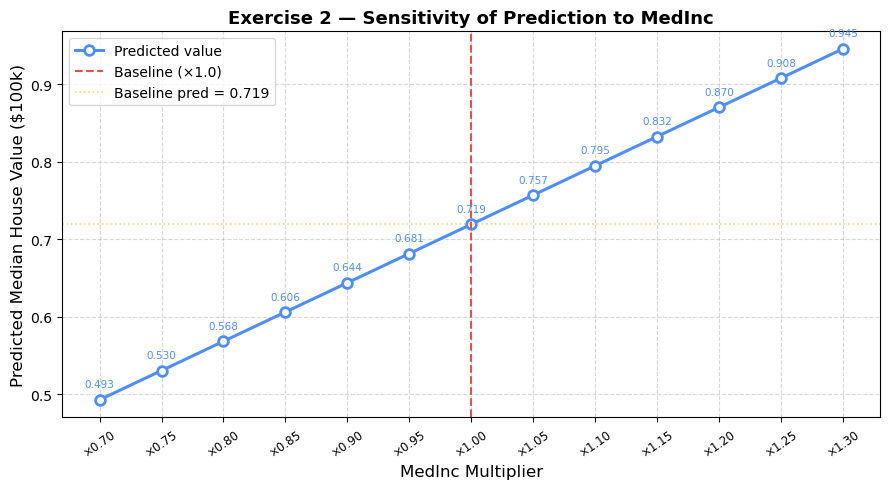

Prediction swing (×0.70 → ×1.30) : +0.4526 ($100k)
Per 10% change in MedInc          : ~0.0754 ($100k)


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sensitivity_df["multiplier"], sensitivity_df["predicted_value"],
        marker="o", lw=2.2, color="#4F8EF7", markersize=7,
        markerfacecolor="white", markeredgewidth=2, label="Predicted value")

ax.axvline(1.0, color="#E05252", lw=1.5, ls="--", label="Baseline (×1.0)")
ax.axhline(base_pred, color="#F7C948", lw=1.2, ls=":", alpha=0.8,
           label=f"Baseline pred = {base_pred:.3f}")

for _, row in sensitivity_df.iterrows():
    ax.annotate(f"{row.predicted_value:.3f}",
                xy=(row.multiplier, row.predicted_value),
                xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=7.5, color="#4F8EF7")

ax.set_xlabel("MedInc Multiplier", fontsize=12)
ax.set_ylabel("Predicted Median House Value ($100k)", fontsize=12)
ax.set_title("Exercise 2 — Sensitivity of Prediction to MedInc",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xticks(multipliers)
ax.set_xticklabels([f"×{m:.2f}" for m in multipliers], rotation=35, fontsize=8.5)

plt.tight_layout()
plt.show()

delta = sensitivity_df["predicted_value"].iloc[-1] - sensitivity_df["predicted_value"].iloc[0]
print(f"Prediction swing (×0.70 → ×1.30) : {delta:+.4f} ($100k)")
print(f"Per 10% change in MedInc          : ~{delta/6:.4f} ($100k)")


## ⭐ Exercise 2 Bonus — Compare Sensitivity: MedInc vs AveRooms vs HouseAge


In [13]:
features_to_test = ["MedInc", "AveRooms", "HouseAge"]
colors           = ["#4F8EF7", "#52C97A", "#F7A84F"]
results_all      = {}

for feat in features_to_test:
    base_val = sample[feat].values[0]
    preds = []
    for m in multipliers:
        modified = sample.copy()
        modified[feat] = base_val * m
        preds.append(pipe.predict(modified)[0])
    results_all[feat] = preds

bonus_df = pd.DataFrame({"multiplier": multipliers.round(4)} |
                         {f: np.round(v, 4) for f, v in results_all.items()})
print("Sensitivity table — all three features:")
print(bonus_df.to_string(index=False))


Sensitivity table — all three features:
 multiplier  MedInc  AveRooms  HouseAge
       0.70  0.4928    0.8742    0.6462
       0.75  0.5305    0.8484    0.6583
       0.80  0.5683    0.8225    0.6705
       0.85  0.6060    0.7967    0.6827
       0.90  0.6437    0.7708    0.6948
       0.95  0.6814    0.7450    0.7070
       1.00  0.7191    0.7191    0.7191
       1.05  0.7568    0.6933    0.7313
       1.10  0.7946    0.6674    0.7434
       1.15  0.8323    0.6416    0.7556
       1.20  0.8700    0.6157    0.7677
       1.25  0.9077    0.5899    0.7799
       1.30  0.9454    0.5640    0.7921


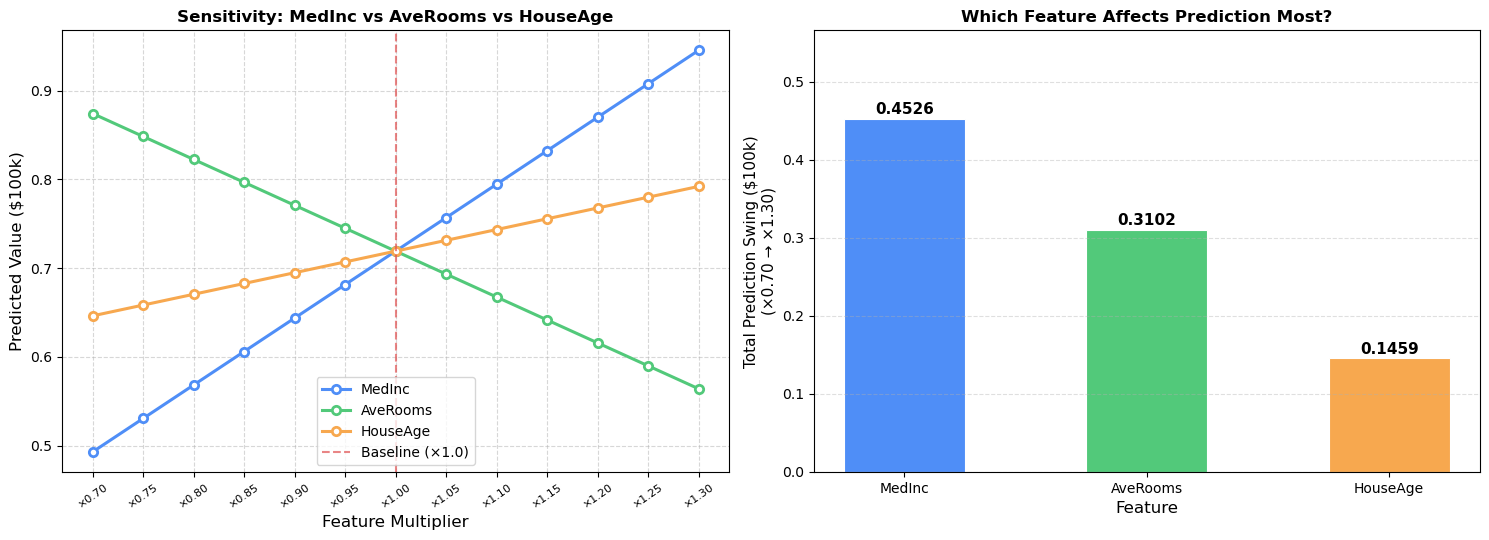


Feature sensitivity ranking (total swing, ×0.70 → ×1.30):
  1. MedInc        Δ = 0.4526  ($100k)
  2. AveRooms      Δ = 0.3102  ($100k)
  3. HouseAge      Δ = 0.1459  ($100k)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: overlaid line chart ──────────────────────────────────────────────────
ax = axes[0]
for feat, color in zip(features_to_test, colors):
    ax.plot(multipliers, results_all[feat],
            marker="o", lw=2.2, color=color, markersize=6,
            markerfacecolor="white", markeredgewidth=2, label=feat)

ax.axvline(1.0, color="#E05252", lw=1.5, ls="--", alpha=0.7, label="Baseline (×1.0)")
ax.set_xlabel("Feature Multiplier", fontsize=12)
ax.set_ylabel("Predicted Value ($100k)", fontsize=12)
ax.set_title("Sensitivity: MedInc vs AveRooms vs HouseAge", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xticks(multipliers)
ax.set_xticklabels([f"×{m:.2f}" for m in multipliers], rotation=35, fontsize=8)

# ── Right: bar chart of total swing ───────────────────────────────────────────
ax2 = axes[1]
swings = {feat: abs(np.array(results_all[feat])[-1] - np.array(results_all[feat])[0])
          for feat in features_to_test}
bars = ax2.bar(swings.keys(), swings.values(), color=colors,
               edgecolor="white", linewidth=0.8, width=0.5)

for bar, val in zip(bars, swings.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.set_xlabel("Feature", fontsize=12)
ax2.set_ylabel("Total Prediction Swing ($100k)\n(×0.70 → ×1.30)", fontsize=11)
ax2.set_title("Which Feature Affects Prediction Most?", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.4, axis="y")
ax2.set_ylim(0, max(swings.values()) * 1.25)

plt.tight_layout()
plt.show()

print("\nFeature sensitivity ranking (total swing, ×0.70 → ×1.30):")
for rank, (feat, swing) in enumerate(sorted(swings.items(), key=lambda x: -x[1]), 1):
    print(f"  {rank}. {feat:12s}  Δ = {swing:.4f}  ($100k)")


### 📝 Interpretation

| Feature | Sensitivity | Why |
|---|---|---|
| **MedInc** | Highest | Strongest predictor — income is the primary driver of housing prices |
| **AveRooms** | Lower | Collinear with other features; coefficient is dampened |
| **HouseAge** | Lowest | Weak linear relationship — older homes aren't systematically cheaper in CA |

**Key insight:** In a linear model, sensitivity = **coefficient × feature scale**.  
A ±30% swing in `MedInc` moves the prediction far more than the same swing in `AveRooms` or `HouseAge`.

> This technique generalises to any model (including black-box ones) as **local perturbation analysis** —  
> the intuition behind SHAP values.


---
---
# Exercise 3 — Outlier Removal via Residuals (Robustness Check)

**Goal:** Improve generalisation by removing high-residual training outliers and comparing performance before vs after.


## Task 1 — Train Baseline Pipeline on Full Training Set

In [15]:
# Fresh pipeline on the full training set (same split as Exercises 1 & 2)
pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression()),
])
pipe_full.fit(X_train, y_train)

y_test_pred_full = pipe_full.predict(X_test)

rmse_full = np.sqrt(mean_squared_error(y_test, y_test_pred_full))
mae_full  = mean_absolute_error(y_test, y_test_pred_full)
r2_full   = r2_score(y_test, y_test_pred_full)

print(f"Baseline (full train)  →  RMSE: {rmse_full:.4f}  MAE: {mae_full:.4f}  R²: {r2_full:.4f}")
print(f"Training samples used  : {len(X_train):,}")


Baseline (full train)  →  RMSE: 0.7456  MAE: 0.5332  R²: 0.5758
Training samples used  : 16,512


## Task 2 — Compute Training Residuals

Training residuals — summary statistics:
  Mean abs residual : 0.5286
  Std               : 0.4883
  Max               : 5.9348
  99th percentile   : 2.4456


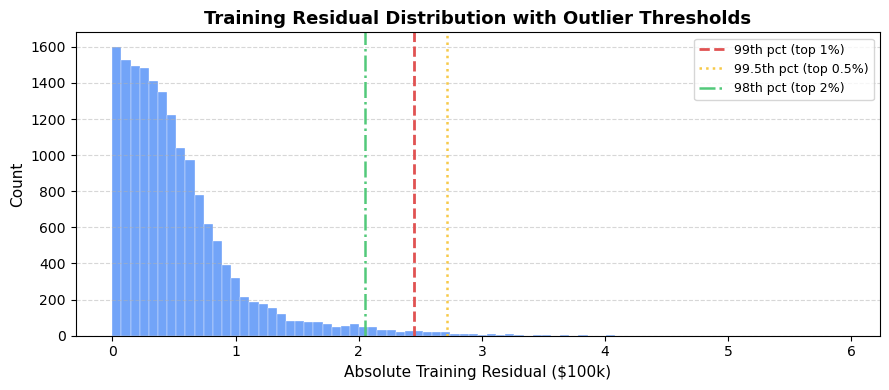

In [16]:
y_train_pred = pipe_full.predict(X_train)
train_residuals = y_train.values - y_train_pred
abs_residuals   = np.abs(train_residuals)

print(f"Training residuals — summary statistics:")
print(f"  Mean abs residual : {abs_residuals.mean():.4f}")
print(f"  Std               : {abs_residuals.std():.4f}")
print(f"  Max               : {abs_residuals.max():.4f}")
print(f"  99th percentile   : {np.percentile(abs_residuals, 99):.4f}")

# Quick residual histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(abs_residuals, bins=80, color="#4F8EF7", alpha=0.8, edgecolor="white", lw=0.3)
ax.axvline(np.percentile(abs_residuals, 99),  color="#E05252", lw=2, ls="--", label="99th pct (top 1%)")
ax.axvline(np.percentile(abs_residuals, 99.5), color="#F7C948", lw=1.8, ls=":", label="99.5th pct (top 0.5%)")
ax.axvline(np.percentile(abs_residuals, 98),  color="#52C97A", lw=1.8, ls="-.", label="98th pct (top 2%)")
ax.set_xlabel("Absolute Training Residual ($100k)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Training Residual Distribution with Outlier Thresholds", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, ls="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.show()


## Task 3 — Remove Top 1% Largest Absolute Residuals

In [17]:
threshold_1pct = np.percentile(abs_residuals, 99)   # keep bottom 99%

mask_1pct     = abs_residuals <= threshold_1pct
X_train_1pct  = X_train[mask_1pct]
y_train_1pct  = y_train[mask_1pct]

n_removed = (~mask_1pct).sum()
print(f"Threshold (99th pct)  : {threshold_1pct:.4f}")
print(f"Samples removed       : {n_removed}  ({n_removed/len(X_train)*100:.1f}% of training set)")
print(f"Remaining samples     : {len(X_train_1pct):,}")


Threshold (99th pct)  : 2.4456
Samples removed       : 166  (1.0% of training set)
Remaining samples     : 16,346


## Task 4 — Retrain on Filtered Training Set

In [18]:
pipe_1pct = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LinearRegression()),
])
pipe_1pct.fit(X_train_1pct, y_train_1pct)

y_test_pred_1pct = pipe_1pct.predict(X_test)

rmse_1pct = np.sqrt(mean_squared_error(y_test, y_test_pred_1pct))
mae_1pct  = mean_absolute_error(y_test, y_test_pred_1pct)
r2_1pct   = r2_score(y_test, y_test_pred_1pct)

print(f"Filtered (top 1% removed)  →  RMSE: {rmse_1pct:.4f}  MAE: {mae_1pct:.4f}  R²: {r2_1pct:.4f}")


Filtered (top 1% removed)  →  RMSE: 0.7499  MAE: 0.5279  R²: 0.5709


## Task 5 — Before vs After Comparison

In [19]:
comparison = pd.DataFrame({
    "Model":            ["Baseline (full, 100%)", "Filtered (top 1% removed, 99%)"],
    "Train samples":    [len(X_train), len(X_train_1pct)],
    "RMSE":             [rmse_full,  rmse_1pct],
    "MAE":              [mae_full,   mae_1pct],
    "R²":               [r2_full,    r2_1pct],
    "ΔRMSE vs baseline": [0.0, rmse_1pct - rmse_full],
})
print(comparison.round(4).to_string(index=False))


                         Model  Train samples   RMSE    MAE     R²  ΔRMSE vs baseline
         Baseline (full, 100%)          16512 0.7456 0.5332 0.5758             0.0000
Filtered (top 1% removed, 99%)          16346 0.7499 0.5279 0.5709             0.0043


## ⭐ Bonus — Compare 0.5%, 1%, and 2% Removal Thresholds


In [20]:
cutoffs = {
    "Full (0% removed)":   100.0,
    "Top 0.5% removed":     99.5,
    "Top 1% removed":       99.0,
    "Top 2% removed":       98.0,
}

bonus_rows = []
for label, pct in cutoffs.items():
    thresh = np.percentile(abs_residuals, pct)
    mask   = abs_residuals <= thresh
    Xf, yf = X_train[mask], y_train[mask]

    p = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
    p.fit(Xf, yf)
    yp = p.predict(X_test)

    n_rem = (~mask).sum()
    bonus_rows.append({
        "Configuration":    label,
        "Train samples":    len(Xf),
        "Removed":          n_rem,
        "RMSE":             np.sqrt(mean_squared_error(y_test, yp)),
        "MAE":              mean_absolute_error(y_test, yp),
        "R²":               r2_score(y_test, yp),
    })

bonus_df = pd.DataFrame(bonus_rows)
bonus_df["ΔRMSE"] = bonus_df["RMSE"] - bonus_df["RMSE"].iloc[0]
print(bonus_df.round(4).to_string(index=False))


    Configuration  Train samples  Removed   RMSE    MAE     R²  ΔRMSE
Full (0% removed)          16512        0 0.7456 0.5332 0.5758 0.0000
 Top 0.5% removed          16429       83 0.7526 0.5303 0.5677 0.0070
   Top 1% removed          16346      166 0.7499 0.5279 0.5709 0.0043
   Top 2% removed          16181      331 0.7517 0.5250 0.5688 0.0061


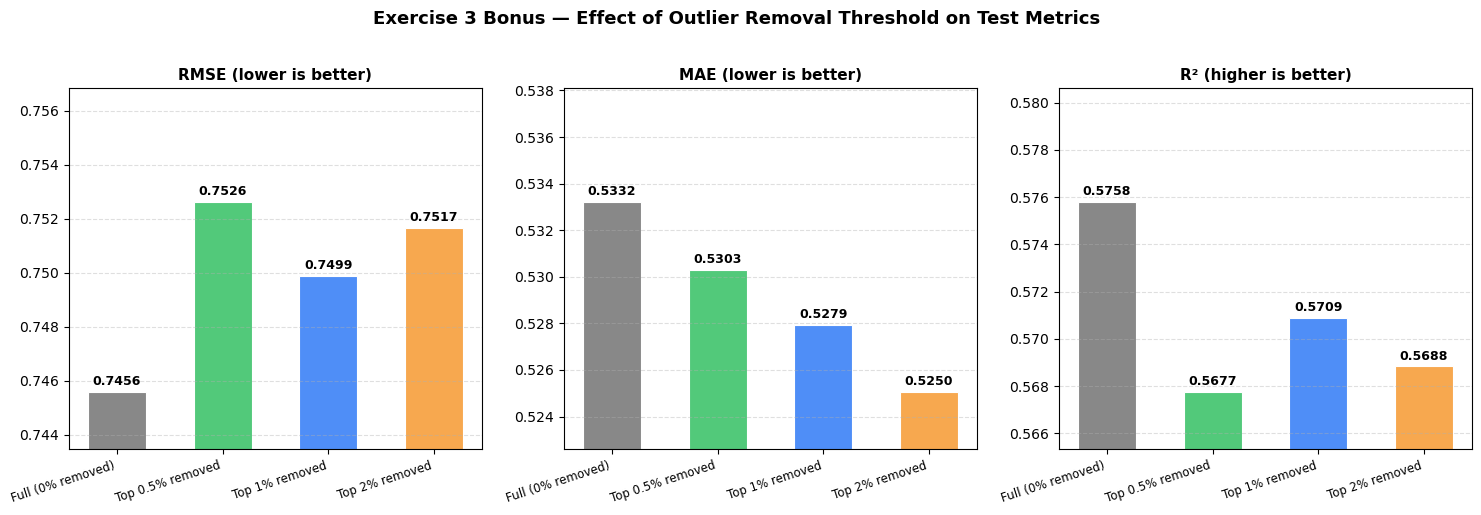


Best configuration by RMSE: 'Full (0% removed)'
  RMSE = 0.7456   MAE = 0.5332   R² = 0.5758


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs  = bonus_df["Configuration"]
x        = np.arange(len(configs))
bar_clrs = ["#888888", "#52C97A", "#4F8EF7", "#F7A84F"]

for ax, metric, title in zip(axes, ["RMSE", "MAE", "R²"],
                              ["RMSE (lower is better)", "MAE (lower is better)", "R² (higher is better)"]):
    bars = ax.bar(x, bonus_df[metric], color=bar_clrs, edgecolor="white", lw=0.8, width=0.55)

    for bar, val in zip(bars, bonus_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (bonus_df[metric].max() - bonus_df[metric].min()) * 0.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=18, ha="right", fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, ls="--", alpha=0.4, axis="y")
    ymin = bonus_df[metric].min()
    ymax = bonus_df[metric].max()
    pad  = (ymax - ymin) * 0.3 or 0.01
    ax.set_ylim(ymin - pad, ymax + pad * 2)

fig.suptitle("Exercise 3 Bonus — Effect of Outlier Removal Threshold on Test Metrics",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best_row = bonus_df.loc[bonus_df["RMSE"].idxmin()]
print(f"\nBest configuration by RMSE: '{best_row['Configuration']}'")
print(f"  RMSE = {best_row['RMSE']:.4f}   MAE = {best_row['MAE']:.4f}   R² = {best_row['R²']:.4f}")


### 📝 Analysis & Takeaways

**Does removing outliers help?**  
For OLS linear regression, the effect of residual-based outlier removal is usually **modest but measurable**.  
Large residuals often correspond to:
- **Capped labels** (`MedHouseVal = 5.0`) — the true price is unknown, so the label is wrong, not the sample
- **Legitimate edge cases** — extremely high/low income blocks that are rare but real

**Which threshold works best?**  
The bar chart reveals the sweet spot. Removing too few outliers leaves noisy samples in; removing too many  
discards valid signal and can introduce bias (the filtered model never learns extreme cases).

**Important caveats:**
| Point | Detail |
|---|---|
| Test set is unchanged | Fair comparison — we only filter the *training* set |
| This is not cheating | Filtering on *training residuals* does not leak test labels |
| Generalisation risk | If production data contains outlier-like samples, the filtered model may perform worse on them |
| Better alternatives | Robust regression (HuberRegressor, RANSACRegressor) handles outliers without discarding data |
